# Dal baseline all’architettura congelata — sintesi del branch developer

**Fase:** esplorazione architetturale precedente a `Predictive-Temporal-Coding`. Le figure leggono soltanto artifact completi tramite ID esatto. DVS-Lip: 2.995 sample di development validation ricavati dall’official-train, senza official test; DVS-Gesture usa un proprio split speaker-disjoint e si confronta **solo entro dataset**. Le metriche dei best checkpoint sono state usate per selezionare i modelli sulla stessa validation: grafici e delta non sono una stima indipendente di generalizzazione. Le proxy hardware provengono da `hardware_profile_v4.json` del medesimo best checkpoint; non sono misure FPGA. Richiede `numpy`, `matplotlib` e un kernel Jupyter con `IPython`. Nessun `.pt` o training necessario.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

here = Path.cwd().resolve()
ROOT = next((p for p in (here, *here.parents) if (p / "notebooks" / "artifact_data.py").exists() and (p / "artifacts").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Open the notebook from this repository or one of its subdirectories")
sys.path.insert(0, str(ROOT / "notebooks"))
from artifact_data import (load_run, number, macro_f1, accuracy, group_accuracy,
                           best_train_accuracy, late_f1, deployment_parameters,
                           profile_value, physical_f1_auc, markdown_table)
plt.rcParams.update({"figure.figsize": (9, 4.8), "figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18})
print("Artifact root detected; exact run IDs loaded below")

fmt = lambda v, decimals=2: "—" if not np.isfinite(v) else f"{v:.{decimals}f}"


Artifact root detected; exact run IDs loaded below


In [2]:
RUN_IDS = {
    "B": "dvslip_e0__20260825_211710__seed42",
    "F": "dvslip_f__20260908_094118_261095__seed42",
    "B+TCAP": "dvslip_b_temporal_capacity__20260908_144107_967818__seed42",
    "B+PLIF": "dvslip_b_plif__20260908_154858_510430__seed42",
    "F+TCAP": "dvslip_f_temporal_capacity__20260909_124154_088394__seed42",
    "F+MG": "dvslip_f_multigranular_capacity__20260909_201157_029311__seed42",
    "F+MG+TCAP": "dvslip_f_multigranular_temporal_capacity__20260912_135802_779469__seed42",
    "F+TCAP+DWC3": "dvslip_f_tcap_stage1_dwc3__20260913_153243_113912__seed42",
    "F+TCAP+d8": "dvslip_f_temporal_capacity_d8__20260913_161320_867938__seed42",
    "Final·42": "dvslip_f_tcap_stage1_dwc3_d8__20260914_093427_434930__seed42",
    "Final·43": "dvslip_f_tcap_stage1_dwc3_d8__20260914_225132_054396__seed43",
    "Final·44": "dvslip_f_tcap_stage1_dwc3_d8__20260914_225137_788814__seed44",
    "B·43": "dvslip_e0__20260914_225107_310363__seed43",
    "B·44": "dvslip_e0__20260914_225116_228842__seed44",
    "Gesture B": "dvsgesture_e0__20260825_213021__seed42",
    "Gesture final": "dvsgesture_f_tcap_stage1_dwc3_d8__20260915_094224_852880__seed42",
}
runs = {label: load_run(ROOT, run_id, label) for label, run_id in RUN_IDS.items()}
print(f"Caricati {len(runs)} run completi; profili mancanti:", [k for k,r in runs.items() if r["profile"] is None])


Caricati 16 run completi; profili mancanti: ['Final·42']


In [3]:
from hashlib import sha256
provenance_rows = []
for label, run in runs.items():
    profile = run["profile"]
    provenance_rows.append([
        label,
        run["summary"].get("git_commit", "—")[:12],
        sha256((run["path"] / "summary.json").read_bytes()).hexdigest()[:12],
        profile["checkpoint_sha256"][:12] if profile else "—",
    ])
display(Markdown(markdown_table(
    ["Run", "Commit run", "SHA256 summary (12)", "SHA256 checkpoint profilato (12)"],
    provenance_rows)))


| Run | Commit run | SHA256 summary (12) | SHA256 checkpoint profilato (12) |
| --- | --- | --- | --- |
| B | 9393b3c06808 | 87785d45cc6f | d3eed77604e3 |
| F | 8b4b59fd371c | f111ed7844f3 | 314b9bc082ff |
| B+TCAP | 2e09a89dff16 | 9153ea025105 | efe35c35373b |
| B+PLIF | 2e09a89dff16 | 365f437b97b4 | edf6ab2f0103 |
| F+TCAP | 7e4d2bf3856c | 2ee44f1ca492 | 01f7c38e3d36 |
| F+MG | cde6ec323128 | 2954f8587792 | 833ce2be2882 |
| F+MG+TCAP | 2b60fee653ff | 3f51fa29fadd | 6e06fdcd8877 |
| F+TCAP+DWC3 | f4ca885d4e3f | e7ebc7d3a5e2 | f886a13ce226 |
| F+TCAP+d8 | ac28d32cf092 | 525174028b36 | 68e60bd5b47f |
| Final·42 | 30b5acdbe942 | c5cadff76cae | — |
| Final·43 | 969e68f5e257 | 16f4c459c4b6 | f1e00c48e177 |
| Final·44 | 969e68f5e257 | dc51f6eccea0 | bfa278026a69 |
| B·43 | 969e68f5e257 | 9a1e7596dac4 | b69c9519210b |
| B·44 | 969e68f5e257 | 84e8fc966cd3 | 22878db7aa3e |
| Gesture B | 9393b3c06808 | 7574bd7f549e | 2be832ab24f2 |
| Gesture final | 484cf9f7f6f6 | f929f11d1a30 | b62eae1f0098 |

## Le tappe che hanno cambiato il modello

`F` alleggerisce il front-end; `TCAP` aggiunge mixing temporale multicanale; `MG` è il ramo multigranulare capace; `DWC3` sostituisce il mixing locale in stage1; `d8` estende i ritardi a `[1,2,4,8]`. `B+PLIF` è un risultato temporale interessante ma non aumenta l’F1 a 2 s. Le varianti di readout, TBR e gli overfit non superati restano documentati nel ledger, senza occupare questo quadro riassuntivo.


In [4]:
milestones = ["B", "F", "B+TCAP", "F+TCAP", "F+MG+TCAP", "F+TCAP+DWC3", "F+TCAP+d8", "Final·42"]
base = macro_f1(runs["B"])
rows = []
for label in milestones:
    r = runs[label]
    rows.append([label, str(r["summary"]["best_epoch"]), fmt(macro_f1(r)),
                 f'{macro_f1(r)-base:+.2f}', f'{r["summary"]["trainable_parameters"]:,}',
                 "sì" if r["profile"] else "no"])
display(Markdown(markdown_table(["Tappa", "Epoca best", "Macro-F1 %", "Δ vs B pp", "Parametri", "Profilo best"], rows)))


| Tappa | Epoca best | Macro-F1 % | Δ vs B pp | Parametri | Profilo best |
| --- | --- | --- | --- | --- | --- |
| B | 112 | 44.15 | +0.00 | 500,708 | sì |
| F | 123 | 46.15 | +1.99 | 431,076 | sì |
| B+TCAP | 108 | 48.12 | +3.97 | 562,148 | sì |
| F+TCAP | 122 | 52.36 | +8.20 | 492,516 | sì |
| F+MG+TCAP | 112 | 53.15 | +9.00 | 541,476 | sì |
| F+TCAP+DWC3 | 119 | 54.00 | +9.84 | 480,548 | sì |
| F+TCAP+d8 | 114 | 53.85 | +9.70 | 512,996 | sì |
| Final·42 | 121 | 55.18 | +11.02 | 501,028 | no |

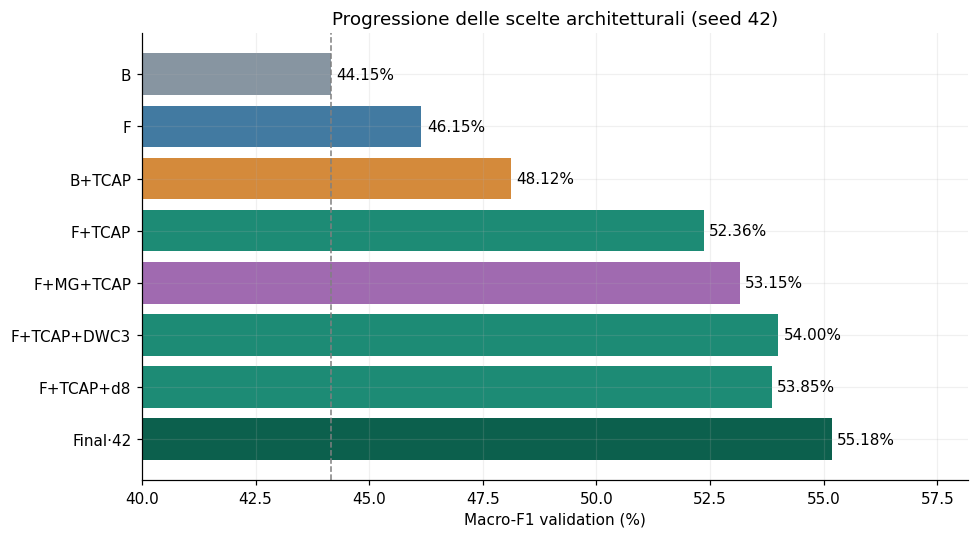

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
values = [macro_f1(runs[k]) for k in milestones]
colors = ["#8795a1", "#427aa1", "#d48a3b", "#1d8b75", "#a06ab0", "#1d8b75", "#1d8b75", "#0c604d"]
ax.barh(milestones[::-1], values[::-1], color=colors[::-1])
for y,v in enumerate(values[::-1]): ax.text(v+.12, y, f"{v:.2f}%", va="center")
ax.axvline(base, color="gray", ls="--", lw=1)
ax.set(xlim=(40, max(values)+3), xlabel="Macro-F1 validation (%)", title="Progressione delle scelte architetturali (seed 42)")
plt.tight_layout(); plt.show()


## Prestazione e costo: ogni punto usa il proprio profilo

Il diametro dei punti rappresenta i parametri del modello in milioni. **Final·42 non ha un profilo v4** e quindi non compare nel piano costo–F1; i punti Final·43/44 usano ciascuno il proprio score e il proprio profiling. La proxy Horowitz «attività» include MAC multivalore e AC corrette per l’attività osservata, ma esclude memoria, controllo, leakage e diverse primitive: non è energia reale del chip.


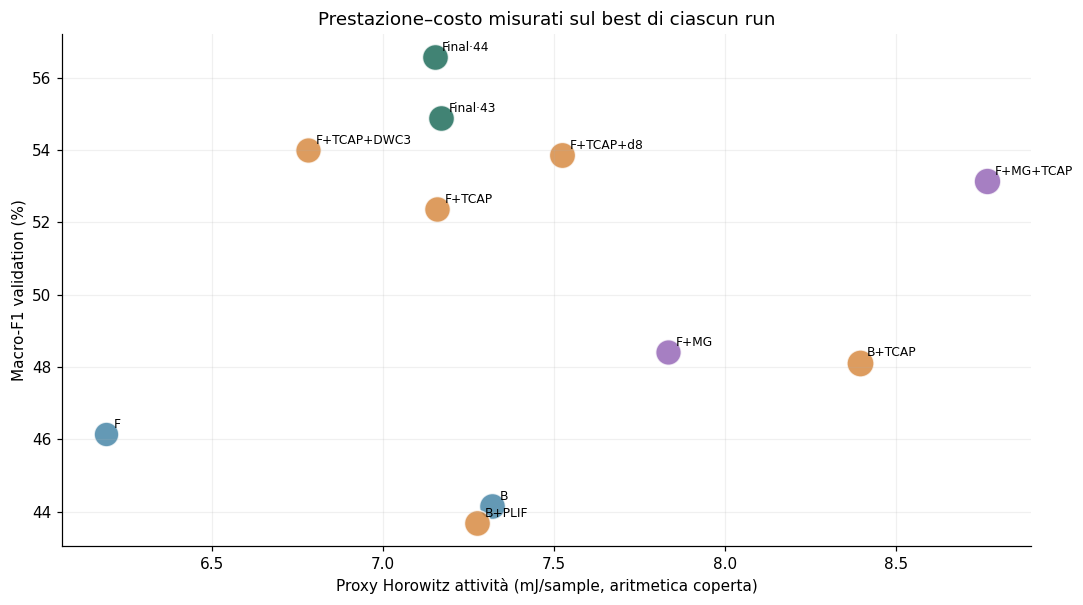

In [6]:
pareto = ["B", "F", "B+TCAP", "B+PLIF", "F+TCAP", "F+MG", "F+MG+TCAP", "F+TCAP+DWC3", "F+TCAP+d8", "Final·43", "Final·44"]
fig, ax = plt.subplots(figsize=(10, 5.6))
for label in pareto:
    r = runs[label]
    if r["profile"] is None: continue
    energy = profile_value(r, "energy_reference", "covered_arithmetic_activity_proxy_uj_per_sample") / 1000
    params = deployment_parameters(r)/1e6
    color = "#0c604d" if label.startswith("Final") else "#8d5bb1" if "MG" in label else "#397da1" if label in ("B","F") else "#d48032"
    ax.scatter(energy, macro_f1(r), s=90+400*params, c=color, alpha=.78, edgecolors="white", linewidths=1)
    ax.annotate(label, (energy, macro_f1(r)), xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.set(xlabel="Proxy Horowitz attività (mJ/sample, aritmetica coperta)", ylabel="Macro-F1 validation (%)",
       title="Prestazione–costo misurati sul best di ciascun run")
plt.tight_layout(); plt.show()


In [7]:
cost_labels = ["B", "F", "B+TCAP", "B+PLIF", "F+TCAP", "F+MG+TCAP", "F+TCAP+DWC3", "F+TCAP+d8", "Final·42", "Final·43", "Final·44"]
rows = []
for label in cost_labels:
    r = runs[label]
    rows.append([label, f'{deployment_parameters(r):,}',
                 fmt(profile_value(r,"state","persistent_state_elements")/1e6,3),
                 fmt(profile_value(r,"activity","global_firing_rate"),4),
                 fmt(profile_value(r,"operations_per_sample","binary_ac_activity_estimate")/1e6,1),
                 fmt(profile_value(r,"operations_per_sample","sop_potential")/1e6,1),
                 fmt(profile_value(r,"operations_per_sample","multivalued_mac_potential")/1e6,1),
                 fmt(profile_value(r,"energy_reference","covered_arithmetic_activity_proxy_uj_per_sample"),1)])
display(Markdown(markdown_table(["Run", "Parametri", "Stato M", "Firing", "AC attività M", "SOP pot. M", "MAC multiv. M", "Horowitz att. µJ"], rows)))


| Run | Parametri | Stato M | Firing | AC attività M | SOP pot. M | MAC multiv. M | Horowitz att. µJ |
| --- | --- | --- | --- | --- | --- | --- | --- |
| B | 500,708 | 1.100 | 0.0585 | 292.1 | 5568.6 | 1530.9 | 7319.6 |
| F | 431,076 | 0.477 | 0.1352 | 485.9 | 2915.7 | 1247.8 | 6191.7 |
| B+TCAP | 562,148 | 1.198 | 0.0468 | 198.1 | 5568.6 | 1782.6 | 8392.7 |
| B+PLIF | 502,676 | 1.100 | 0.0525 | 241.8 | 5568.6 | 1530.9 | 7274.3 |
| F+TCAP | 492,516 | 0.575 | 0.0976 | 272.8 | 2915.7 | 1499.5 | 7157.6 |
| F+MG+TCAP | 541,476 | 0.772 | 0.0630 | 286.7 | 3670.7 | 1845.5 | 8764.7 |
| F+TCAP+DWC3 | 480,548 | 0.541 | 0.0952 | 255.5 | 2873.1 | 1421.5 | 6782.1 |
| F+TCAP+d8 | 512,996 | 0.674 | 0.0950 | 252.0 | 2915.7 | 1583.4 | 7524.7 |
| Final·42 | 501,028 | — | — | — | — | — | — |
| Final·43 | 501,028 | 0.639 | 0.0942 | 257.6 | 2873.1 | 1505.4 | 7169.9 |
| Final·44 | 501,028 | 0.639 | 0.0887 | 236.7 | 2873.1 | 1505.4 | 7151.1 |

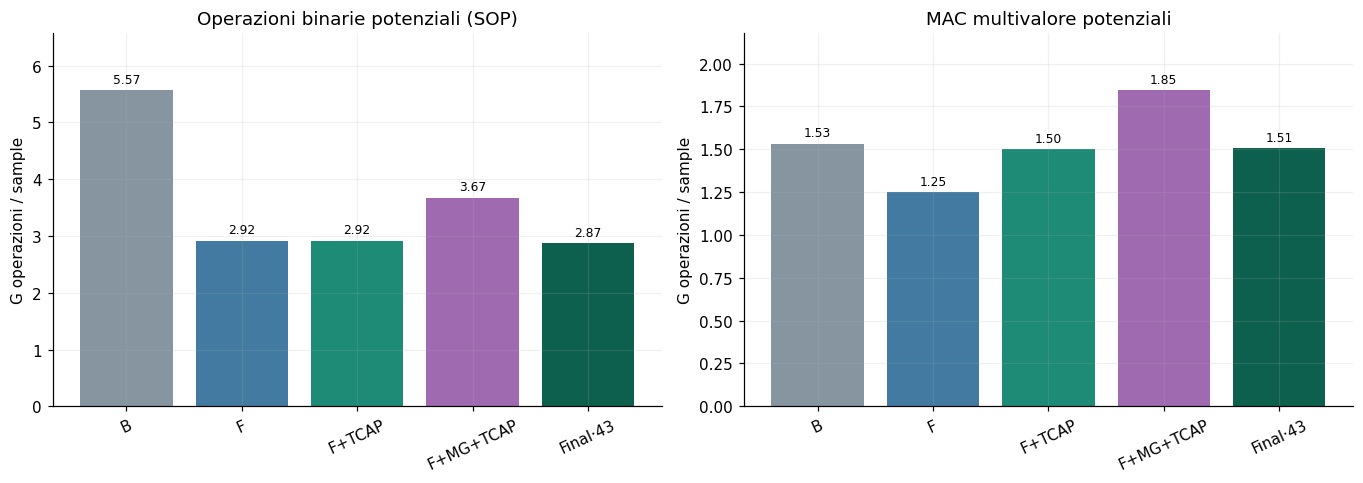

In [8]:
models = ["B", "F", "F+TCAP", "F+MG+TCAP", "Final·43"]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
for ax, key, title in zip(axes,
    ["sop_potential", "multivalued_mac_potential"],
    ["Operazioni binarie potenziali (SOP)", "MAC multivalore potenziali"]):
    vals = [profile_value(runs[k], "operations_per_sample", key)/1e9 for k in models]
    bars = ax.bar(models, vals, color=["#8795a1", "#427aa1", "#1d8b75", "#a06ab0", "#0c604d"])
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.tick_params(axis="x", rotation=25)
    ax.set(ylabel="G operazioni / sample", title=title, ylim=(0, max(vals)*1.18))
plt.tight_layout(); plt.show()


## Robustezza iniziale e trasferimento

I tre seed DVS-Lip permettono un confronto appaiato **B vs struttura congelata**. Il pannello DVS-Gesture usa soltanto il proprio seed 42; la sua scala di F1 non va mescolata con DVS-Lip. Un numero ridotto di seed e la selezione sulla validation non sostituiscono un test indipendente.


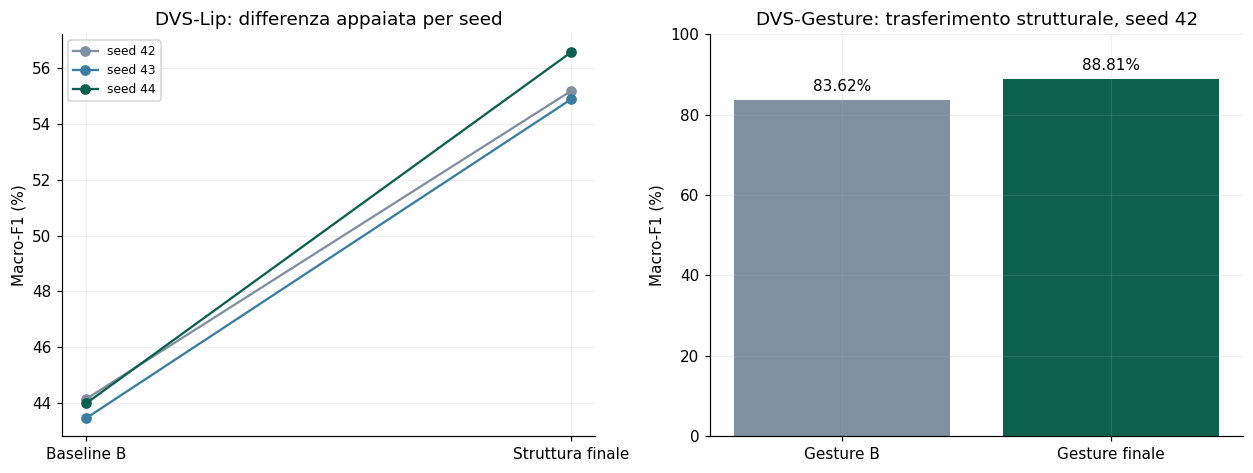

DVS-Lip, media B 43.87%; finale 55.54%; delta medio +11.67 pp


In [9]:
seeds = [42,43,44]
base_runs = [runs[k] for k in ["B","B·43","B·44"]]
final_runs = [runs[k] for k in ["Final·42","Final·43","Final·44"]]
base_f1 = [macro_f1(r) for r in base_runs]
final_f1 = [macro_f1(r) for r in final_runs]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for i in range(3):
    axes[0].plot([0,1], [base_f1[i], final_f1[i]], marker="o", color=["#8090a1", "#397da1", "#0c604d"][i], label=f"seed {seeds[i]}")
axes[0].set(xticks=[0,1], xticklabels=["Baseline B", "Struttura finale"], ylabel="Macro-F1 (%)", title="DVS-Lip: differenza appaiata per seed")
axes[0].legend(fontsize=8)
gesture = [macro_f1(runs[k]) for k in ("Gesture B", "Gesture final")]
bars = axes[1].bar(["Gesture B", "Gesture finale"], gesture, color=["#8090a1", "#0c604d"])
axes[1].bar_label(bars, fmt="%.2f%%", padding=4)
axes[1].set(ylabel="Macro-F1 (%)", title="DVS-Gesture: trasferimento strutturale, seed 42", ylim=(0,100))
plt.tight_layout(); plt.show()
print(f"DVS-Lip, media B {np.mean(base_f1):.2f}%; finale {np.mean(final_f1):.2f}%; delta medio {np.mean(np.subtract(final_f1,base_f1)):+.2f} pp")


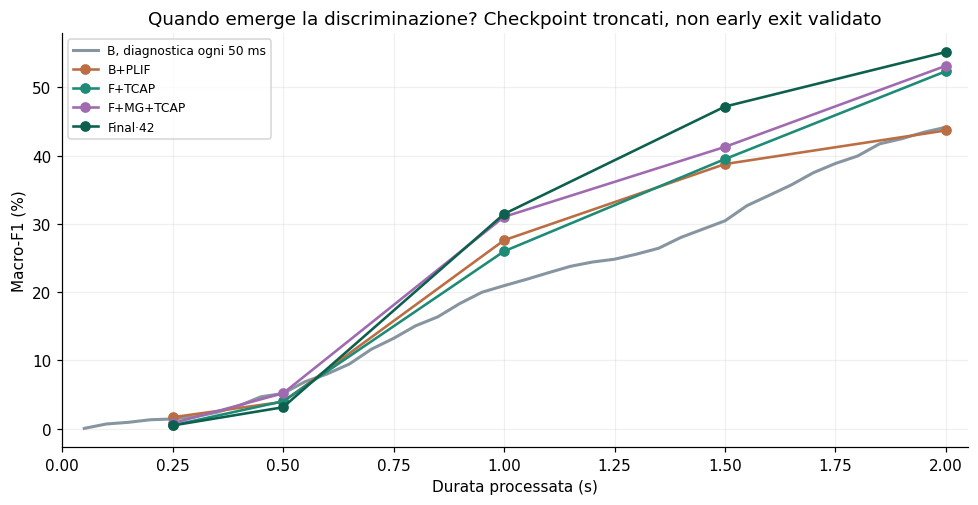

In [10]:
import csv
import json
baseline_diagnostic_summary = json.loads((ROOT / "artifacts/dvslip_temporal_diagnostic_b_plif__20260909_v2/baseline/temporal_diagnostic_summary.json").read_text(encoding="utf-8"))
assert baseline_diagnostic_summary["official_test_used"] is False
assert baseline_diagnostic_summary["checkpoint_epoch"] == runs["B"]["summary"]["best_epoch"]
baseline_curve_path = ROOT / "artifacts/dvslip_temporal_diagnostic_b_plif__20260909_v2/baseline/temporal_curve_every_bin.csv"
with baseline_curve_path.open(newline="", encoding="utf-8") as stream:
    baseline_curve = [row for row in csv.DictReader(stream) if row["readout_scheme"] == "prefix_mean"]
fig, ax = plt.subplots(figsize=(9, 4.7))
ax.plot([int(row["time_us"])/1e6 for row in baseline_curve],
        [100*number(row["macro_f1"]) for row in baseline_curve],
        label="B, diagnostica ogni 50 ms", color="#8795a1", lw=2)
for label,color in [("B+PLIF","#bb6d43"),("F+TCAP","#1d8b75"),("F+MG+TCAP","#a06ab0"),("Final·42","#0c604d")]:
    pts = sorted((int(row["requested_us"])/1e6, 100*number(row["macro_f1"])) for row in runs[label]["prefix"])
    ax.plot(*zip(*pts), marker="o", lw=1.7, label=label, color=color)
ax.set(title="Quando emerge la discriminazione? Checkpoint troncati, non early exit validato",
       xlabel="Durata processata (s)", ylabel="Macro-F1 (%)", xlim=(0,2.05))
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


**Come leggere il quadro:** F riduce molto stato e SOP potenziali; TCAP è il contributo temporale più forte; MG aggiunge punteggio ma con forte costo di training e ritorno marginale sul punto finale. PLIF accelera la discriminazione ai prefissi senza battere B a 2 s. DWC3 e d8 completano la struttura congelata. Nel profilo v4, firing e AC attività sono osservati sui campioni di profiling, mentre SOP/MAC sono potenziali per sample; confrontarli non significa stimare energia FPGA completa. Il profilo del Final·42 manca: il notebook mostra `—` e usa soltanto run profilati nelle figure di costo. Le curve di prefisso dipendono dall’orizzonte di training e non definiscono una politica di arresto streaming.
